In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.read_excel("KNN_Supervised.xlsx")
print(data.head())

  Student  Study Hours  Sleep Hours Result
0      S1            2            6   Fail
1      S2            3            7   Fail
2      S3            4            6   Pass
3      S4            5            5   Pass
4      S5            6            6   Pass


In [4]:
data = data.drop("Student", axis=1)
print(data.head())

   Study Hours  Sleep Hours Result
0            2            6   Fail
1            3            7   Fail
2            4            6   Pass
3            5            5   Pass
4            6            6   Pass


In [5]:
le = LabelEncoder()
data["Result"] = le.fit_transform(data["Result"])

print(data.head())

   Study Hours  Sleep Hours  Result
0            2            6       0
1            3            7       0
2            4            6       1
3            5            5       1
4            6            6       1


In [6]:
X = data[["Study Hours","Sleep Hours"]]
y = data["Result"]

In [7]:
X

,Study Hours,Sleep Hours
0,2,6
1,3,7
2,4,6
3,5,5
4,6,6
5,1,8
6,7,5
7,2,7
8,6,5
9,3,6


In [8]:
y

0    0
1    0
2    1
3    1
4    1
5    0
6    1
7    0
8    1
9    0
Name: Result, dtype: int32

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [11]:
y_pred = knn.predict(X_test)

print("Predictions:", y_pred)

Predictions: [1 0]


In [16]:
prediction = knn.predict([[4, 5]])

print(prediction)

[1]


c:\Users\hpvan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


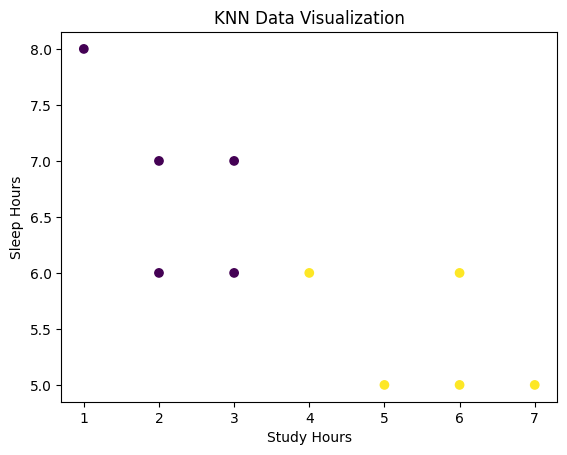

In [13]:
import matplotlib.pyplot as plt

plt.scatter(data["Study Hours"], data["Sleep Hours"], c=data["Result"])

plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("KNN Data Visualization")

plt.show()

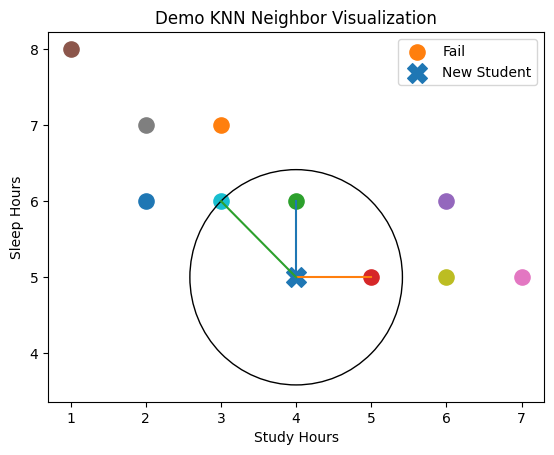

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# training data
X_points = data[["Study Hours","Sleep Hours"]].values
y_points = data["Result"].values

# new student
new_point = np.array([4,5])

# calculate distances
distances = np.sqrt(np.sum((X_points - new_point)**2, axis=1))

# combine data
neighbors = list(zip(X_points, y_points, distances))

# sort by distance
neighbors.sort(key=lambda x: x[2])

k = 3
k_neighbors = neighbors[:k]

# plot dataset
for i, point in enumerate(X_points):
    if y_points[i] == 1:
        plt.scatter(point[0], point[1], s=120, label="Pass" if i==0 else "")
    else:
        plt.scatter(point[0], point[1], s=120, label="Fail" if i==1 else "")

# plot new point
plt.scatter(new_point[0], new_point[1], s=200, marker="X", label="New Student")

# draw lines to K neighbors
for n in k_neighbors:
    p = n[0]
    plt.plot([new_point[0], p[0]], [new_point[1], p[1]])

# draw circle showing neighbor boundary
radius = k_neighbors[-1][2]
circle = plt.Circle((new_point[0], new_point[1]), radius, fill=False)
plt.gca().add_patch(circle)

plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Demo KNN Neighbor Visualization")
plt.legend()
plt.show()